# Exploratory Data Analysis: IBM AML Synthetic Dataset (HI-Small)

## Anti-Money Laundering with Graph Neural Networks — Master Thesis

---

### Background

**Anti-Money Laundering (AML)** is the process of detecting the illegal practice of disguising the origins of illicitly obtained funds by passing them through a complex sequence of banking transfers or commercial transactions. Money laundering is estimated to account for 2–5% of global GDP (~\$1.7–4T annually), yet current rule-based detection systems suffer from very high false positive rates.

### Dataset

This notebook analyses the **HI-Small** (Higher Illicit ratio, Small — [Kaggle link](https://www.kaggle.com/datasets/ealtman2019/ibm-transactions-for-anti-money-laundering-aml/data)) variant of the **IBM Transactions for Anti-Money Laundering (AML)** synthetic dataset, introduced by Altman et al. (2023, *"Realistic Synthetic Financial Transactions for Anti-Money Laundering Models"*). It extends my earlier graph-mining course project, which used the LI-Small (Lower Illicit ratio) variant: HI-Small has roughly **2× the laundering rate** and substantially more laundering pattern attempts, giving richer supervision for GNN training.

| File | Description |
|------|-------------|
| `HI-Small_Trans.csv` | ~5.1M transaction records with laundering labels |
| `HI-Small_accounts.csv` | Account master data (bank, entity ID, entity name) |
| `HI-Small_Patterns.txt` | Ground-truth laundering pattern annotations |

### Goals of this EDA

1. Understand class imbalance, amount, temporal, and categorical distributions
2. Characterise the transaction network topology (degrees, self-loops, hubs)
3. Map every finding to a concrete feature-engineering decision for the GNN pipeline

## 1. Setup & Imports

In [8]:
import re
import warnings
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import yfinance as yf

warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.dpi'] = 100
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')

## 2. Data Loading & Initial Overview

> **Note:** The transaction CSV uses the header name `Account` twice (sender and receiver), so we supply explicit column names on load.

In [9]:
col_names = [
    'Timestamp', 'From Bank', 'From Account',
    'To Bank', 'To Account',
    'Amount Received', 'Receiving Currency',
    'Amount Paid', 'Payment Currency',
    'Payment Format', 'Is Laundering'
]

df = pd.read_csv('Data/HI-Small_Trans.csv', names=col_names, header=0, low_memory=False)
df['Timestamp'] = pd.to_datetime(df['Timestamp'])

print(f'Transactions: {df.shape[0]:,} rows x {df.shape[1]} columns')
print(f'Date range:   {df["Timestamp"].min()} -> {df["Timestamp"].max()}')
df.head()

Transactions: 5,078,345 rows x 11 columns
Date range:   2022-09-01 00:00:00 -> 2022-09-18 16:18:00


,Timestamp,From Bank,From Account,To Bank,To Account,Amount Received,Receiving Currency,Amount Paid,Payment Currency,Payment Format,Is Laundering
0,2022-09-01 00:20:00,10,8000EBD30,10,8000EBD30,"3,697.3400",US Dollar,"3,697.3400",US Dollar,Reinvestment,0
1,2022-09-01 00:20:00,3208,8000F4580,1,8000F5340,0.0100,US Dollar,0.0100,US Dollar,Cheque,0
2,2022-09-01 00:00:00,3209,8000F4670,3209,8000F4670,"14,675.5700",US Dollar,"14,675.5700",US Dollar,Reinvestment,0
3,2022-09-01 00:02:00,12,8000F5030,12,8000F5030,"2,806.9700",US Dollar,"2,806.9700",US Dollar,Reinvestment,0
4,2022-09-01 00:06:00,10,8000F5200,10,8000F5200,"36,682.9700",US Dollar,"36,682.9700",US Dollar,Reinvestment,0


In [10]:
accounts = pd.read_csv('Data/HI-Small_accounts.csv', low_memory=False)
print(f'Accounts: {accounts.shape[0]:,} rows x {accounts.shape[1]} columns')
accounts.head()

Accounts: 518,581 rows x 5 columns


,Bank Name,Bank ID,Account Number,Entity ID,Entity Name
0,Portugal Bank #4507,331579,80B779D80,80062E240,Sole Proprietorship #50438
1,Canada Bank #27,210,809D86900,800C998A0,Corporation #33520
2,UK Bank #33,21884,80812BE00,800C47F50,Partnership #35397
3,Germany Bank #4815,32742,81047F300,80096F0B0,Corporation #48813
4,National Bank of Harrisburg,127390,80BD8CF00,800FB8760,Corporation #889


In [11]:
print(f'Missing values:       {df.isnull().sum().sum()}')
print(f'Exact duplicate rows: {df.duplicated().sum()}')
df[['Amount Received', 'Amount Paid', 'Is Laundering']].describe([0.01, 0.5, 0.99])

Missing values:       0
Exact duplicate rows: 9


,Amount Received,Amount Paid,Is Laundering
count,"5,078,345.0000","5,078,345.0000","5,078,345.0000"
mean,"5,988,726.0701","4,509,273.3677",0.0010
std,"1,037,183,108.8920","869,772,830.9199",0.0319
min,0.0000,0.0000,0.0000
1%,0.0168,0.0185,0.0000
50%,"1,411.0100","1,414.5400",0.0000
99%,"14,751,232.4600","13,524,530.7056",0.0000
max,"1,046,302,363,293.4800","1,046,302,363,293.4800",1.0000


### Interpretation

- The dataset is **complete** (no missing values) with only 9 exact duplicate rows out of 5.08M — negligible.
- The dataset spans **2022-09-01 to 2022-09-18**, but as shown later, meaningful volume only covers the first ~10 days.
- `Amount Paid` / `Amount Received` are denominated in each transaction's **native currency**, so the raw statistics are misleading: the maximum "amount" of ~1.05 trillion is a **Yen** transaction, not a trillion dollars. This makes cross-currency comparison meaningless and motivates the next section: **converting all amounts to USD**.
- The binary `Is Laundering` column (0 = normal, 1 = laundering) is the prediction target.

## 3. Converting Amounts to USD

The dataset contains **15 currencies** whose units differ by orders of magnitude (1,000 Yen ≈ \$7, while 1,000 Bitcoin ≈ \$19M in Sep 2022). Without conversion, a model would see structurally identical laundering patterns at wildly different numeric scales depending on currency, making it impossible to learn a unified amount signal.

**Approach** (same as in my previous LI-Small work): fetch **day-specific close rates** from Yahoo Finance for the exact date range of the dataset, forward-fill weekends from the last trading close, and convert `Amount Paid` to `Amount_USD`. USD rows keep rate = 1.0. All later amount analysis uses `Amount_USD`.

In [12]:
# Yahoo Finance tickers for the 14 non-USD currencies in HI-Small
CURRENCY_TICKER = {
    'Australian Dollar': 'AUDUSD=X', 'Bitcoin':         'BTC-USD',
    'Brazil Real':       'BRLUSD=X', 'Canadian Dollar': 'CADUSD=X',
    'Euro':              'EURUSD=X', 'Mexican Peso':    'MXNUSD=X',
    'Ruble':             'RUBUSD=X', 'Rupee':           'INRUSD=X',
    'Saudi Riyal':       'SARUSD=X', 'Shekel':          'ILSUSD=X',
    'Swiss Franc':       'CHFUSD=X', 'UK Pound':        'GBPUSD=X',
    'Yen':               'JPYUSD=X', 'Yuan':            'CNYUSD=X',
}

dates = pd.date_range('2022-09-01', '2022-09-18')
fx_rate = {}  # (currency, 'YYYY-MM-DD') -> rate to USD

for currency, ticker in CURRENCY_TICKER.items():
    close = yf.download(ticker, start='2022-09-01', end='2022-09-19',
                        auto_adjust=True, progress=False)['Close']
    close = close.squeeze().reindex(dates).ffill().bfill()  # fill weekends
    for day, rate in close.items():
        fx_rate[(currency, str(day.date()))] = float(rate)
    print(f'{currency:18s} {ticker:9s} last close = {float(close.iloc[-1]):.4f}')

Australian Dollar  AUDUSD=X  last close = 0.6687
Bitcoin            BTC-USD   last close = 19419.5059
Brazil Real        BRLUSD=X  last close = 0.1906
Canadian Dollar    CADUSD=X  last close = 0.7549
Euro               EURUSD=X  last close = 0.9988
Mexican Peso       MXNUSD=X  last close = 0.0498
Ruble              RUBUSD=X  last close = 0.0168
Rupee              INRUSD=X  last close = 0.0125
Saudi Riyal        SARUSD=X  last close = 0.2665
Shekel             ILSUSD=X  last close = 0.2916
Swiss Franc        CHFUSD=X  last close = 1.0397
UK Pound           GBPUSD=X  last close = 1.1453
Yen                JPYUSD=X  last close = 0.0070
Yuan               CNYUSD=X  last close = 0.1430


In [13]:
# Map each (currency, day) pair to its rate and convert; USD rows keep rate 1.0
df['Date'] = df['Timestamp'].dt.date.astype(str)
pairs = df[['Payment Currency', 'Date']].drop_duplicates()
pairs['FX_Rate'] = [fx_rate.get((c, d), 1.0)
                    for c, d in zip(pairs['Payment Currency'], pairs['Date'])]

df = df.merge(pairs, on=['Payment Currency', 'Date'], how='left')
df['Amount_USD'] = df['Amount Paid'] * df['FX_Rate']

pd.DataFrame({
    'Raw (native currency units)': df['Amount Paid'].describe([0.5, 0.99]),
    'Converted (USD)':             df['Amount_USD'].describe([0.5, 0.99]),
})

,Raw (native currency units),Converted (USD)
count,"5,078,345.0000","5,078,345.0000"
mean,"4,509,273.3677","344,207.8142"
std,"869,772,830.9199","24,604,066.6355"
min,0.0000,0.0001
50%,"1,414.5400",862.5400
99%,"13,524,530.7056","3,031,007.7006"
max,"1,046,302,363,293.4800","29,097,033,049.1299"


### Interpretation

- After conversion the median transaction is **\$863** and the 99th percentile ~\$3.0M — a coherent, single-scale distribution.
- The maximum drops from 1.05 trillion (raw Yen units) to ~\$29B (a large Brazil Real transfer) — still an extreme heavy tail, handled by log-transformation in Section 5.

## 4. Target Variable: Class Imbalance

In real AML data only a tiny fraction of transactions is suspicious. A naive classifier predicting "normal" everywhere would reach ~99.9% accuracy while catching zero launderers, so quantifying the imbalance drives both the **loss design** and the **evaluation metrics** of the GNN.

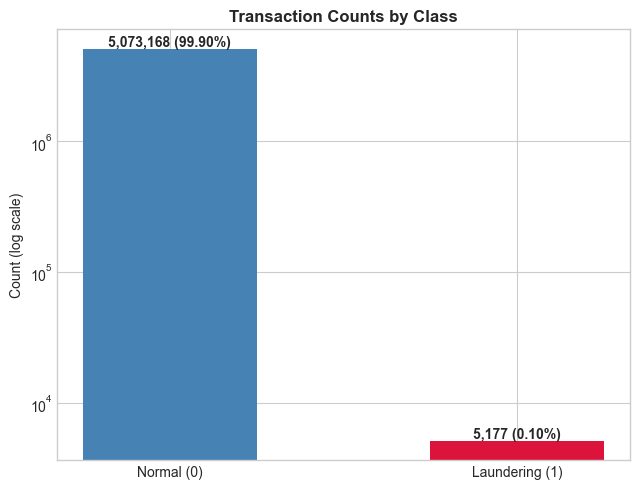

Laundering rate: 0.1019% (1 laundering per 980 normal transactions)


In [15]:
label_counts = df['Is Laundering'].value_counts()
pct = label_counts / len(df) * 100

fig, ax = plt.subplots(figsize=(6.5, 5))
ax.bar(['Normal (0)', 'Laundering (1)'], label_counts.values,
       color=['steelblue', 'crimson'], width=0.5)
ax.set_yscale('log')
ax.set_ylabel('Count (log scale)')
ax.set_title('Transaction Counts by Class', fontweight='bold')
for i, (v, p) in enumerate(zip(label_counts.values, pct.values)):
    ax.text(i, v, f'{v:,} ({p:.2f}%)', ha='center', va='bottom', fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Laundering rate: {df["Is Laundering"].mean():.4%} '
      f'(1 laundering per {label_counts[0] / label_counts[1]:,.0f} normal transactions)')

### Interpretation

- The laundering rate is **~0.102%** (5,177 of 5.08M transactions) — a **1 : 980** class ratio.
- This is roughly **2× the LI-Small rate** (~0.05%), which is exactly the "Higher Illicit" property of this variant — more positive examples for training, while remaining realistically imbalanced.
- **Implications for the GNN:** standard cross-entropy collapses to the majority class, so a **class-weighted loss** (or minority oversampling) is required, and evaluation must use **minority-class F1, PR-AUC, or Precision/Recall@K** rather than accuracy.

## 5. Transaction Amount Analysis (USD)

Money laundering often involves *structuring* (splitting large sums into many smaller transfers below reporting thresholds) or large layering transfers. We compare the USD amount distributions of normal vs. laundering transactions.

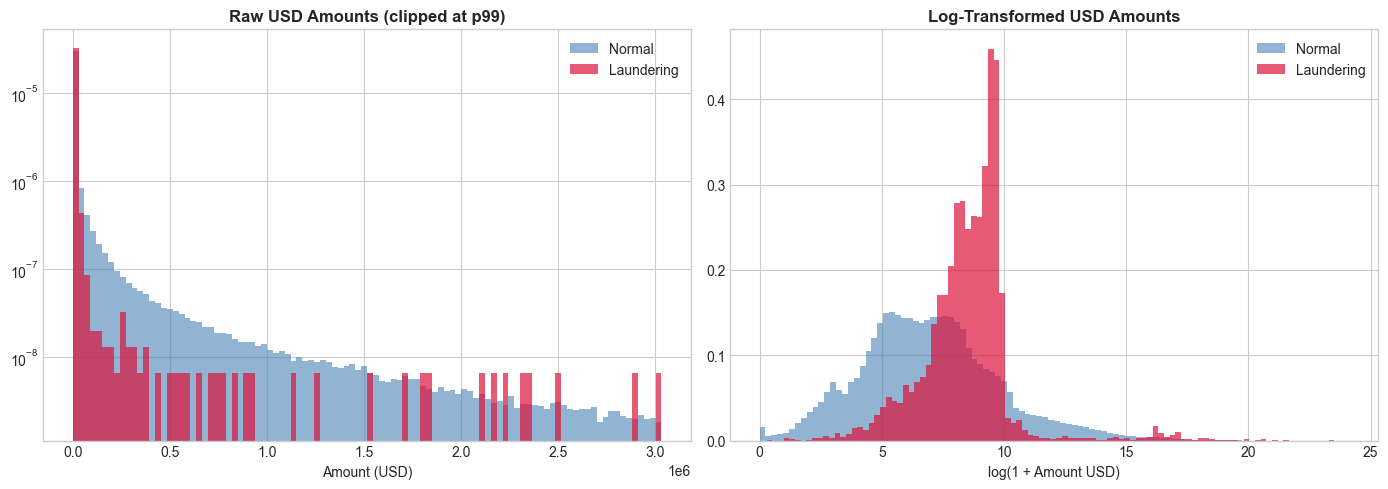

Median amount   normal: $860   laundering: $5,666
Laundering IQR: $2,046 - $12,859


In [16]:
normal_usd = df.loc[df['Is Laundering'] == 0, 'Amount_USD']
laund_usd  = df.loc[df['Is Laundering'] == 1, 'Amount_USD']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Raw USD distribution, clipped at the 99th percentile for readability
clip = df['Amount_USD'].quantile(0.99)
bins = np.histogram_bin_edges(df.loc[df['Amount_USD'] <= clip, 'Amount_USD'], bins=100)
axes[0].hist(normal_usd[normal_usd <= clip], bins=bins, color='steelblue',
             alpha=0.6, label='Normal', density=True)
axes[0].hist(laund_usd[laund_usd <= clip], bins=bins, color='crimson',
             alpha=0.7, label='Laundering', density=True)
axes[0].set_yscale('log')
axes[0].set_xlabel('Amount (USD)')
axes[0].set_title('Raw USD Amounts (clipped at p99)', fontweight='bold')
axes[0].legend()

axes[1].hist(np.log1p(normal_usd), bins=100, color='steelblue', alpha=0.6,
             label='Normal', density=True)
axes[1].hist(np.log1p(laund_usd), bins=100, color='crimson', alpha=0.7,
             label='Laundering', density=True)
axes[1].set_xlabel('log(1 + Amount USD)')
axes[1].set_title('Log-Transformed USD Amounts', fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f'Median amount   normal: ${normal_usd.median():,.0f}   laundering: ${laund_usd.median():,.0f}')
print(f'Laundering IQR: ${laund_usd.quantile(0.25):,.0f} - ${laund_usd.quantile(0.75):,.0f}')

### Interpretation

- The USD amount distribution is **heavily right-skewed**; after `log(1+x)` it becomes approximately bell-shaped (log-normal), so **log-transforming the USD amount is essential** before using it as a model feature.
- Laundering transactions concentrate in a **mid-range band**: median ≈ \$5.7K, interquartile range ≈ \$2K–\$13K — launderers avoid both trivially small and conspicuously large transfers.
- There is **no clean amount threshold** separating the classes, so amount alone is a weak signal — but a useful one in combination with structural features.

## 6. Temporal Patterns

Timing can carry behavioural signal: legitimate activity follows business hours and weekdays, while laundering may not. We check volume stability over the observation window and laundering rates by hour and day of week.

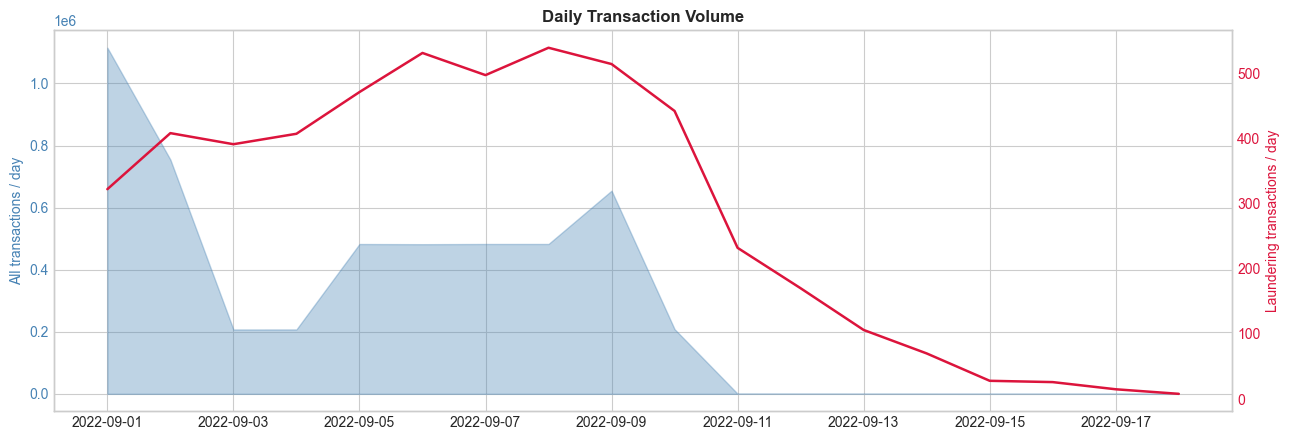

In [17]:
daily = df.groupby(df['Timestamp'].dt.date).agg(
    Total=('Is Laundering', 'count'),
    Laundering=('Is Laundering', 'sum'),
)

fig, ax1 = plt.subplots(figsize=(13, 4.5))
ax1.fill_between(daily.index, daily['Total'], alpha=0.35, color='steelblue')
ax1.set_ylabel('All transactions / day', color='steelblue')
ax1.tick_params(axis='y', labelcolor='steelblue')

ax2 = ax1.twinx()
ax2.plot(daily.index, daily['Laundering'], color='crimson', lw=1.8)
ax2.set_ylabel('Laundering transactions / day', color='crimson')
ax2.tick_params(axis='y', labelcolor='crimson')
ax2.grid(False)

plt.title('Daily Transaction Volume', fontweight='bold')
plt.tight_layout()
plt.show()

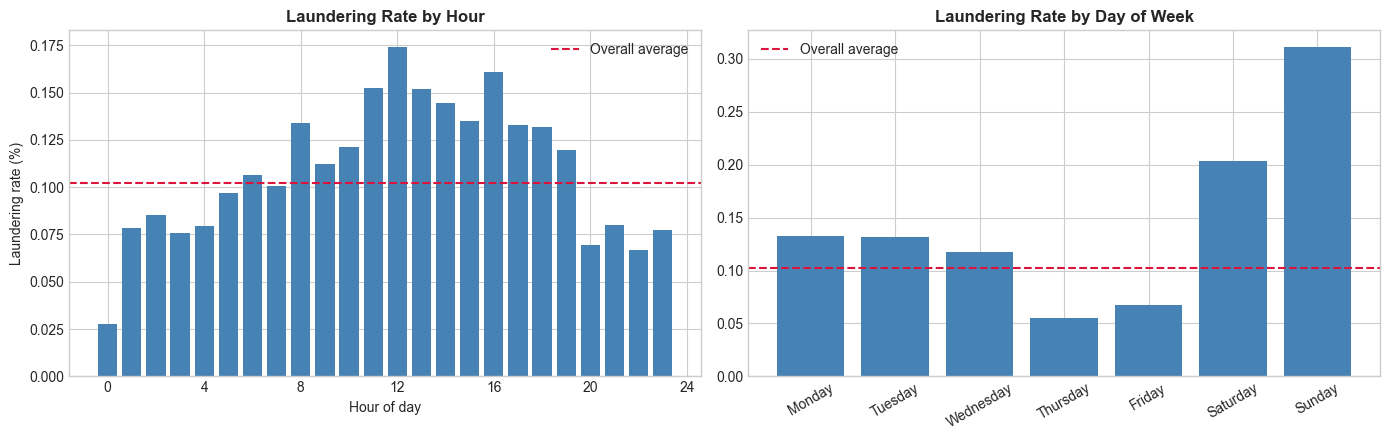

In [18]:
hourly = df.groupby(df['Timestamp'].dt.hour)['Is Laundering'].mean() * 100
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
dow = df.groupby(df['Timestamp'].dt.day_name())['Is Laundering'].mean().reindex(day_order) * 100
overall = df['Is Laundering'].mean() * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

axes[0].bar(hourly.index, hourly.values, color='steelblue')
axes[0].axhline(overall, color='crimson', ls='--', label='Overall average')
axes[0].set_xlabel('Hour of day')
axes[0].set_ylabel('Laundering rate (%)')
axes[0].set_title('Laundering Rate by Hour', fontweight='bold')
axes[0].xaxis.set_major_locator(mticker.MultipleLocator(4))
axes[0].legend()

axes[1].bar(day_order, dow.values, color='steelblue')
axes[1].axhline(overall, color='crimson', ls='--', label='Overall average')
axes[1].set_title('Laundering Rate by Day of Week', fontweight='bold')
axes[1].tick_params(axis='x', rotation=30)
axes[1].legend()

plt.tight_layout()
plt.show()

### Interpretation

- Volume is **not stable over time**: full activity runs 2022-09-01 to 2022-09-10 (with weekend dips), then collapses to near zero from 2022-09-11 onward. A **temporal train/validation/test split** must account for this truncated tail to avoid distorted test sets.
- The hourly laundering rate follows **business hours**: lowest at midnight (~0.03%) and peaking around midday (~0.17% at 12:00).
- **Weekends are strongly elevated**: Sunday ~0.31% and Saturday ~0.20% vs. ~0.06–0.13% on weekdays — laundering concentrates when institutional oversight is reduced.
- **Feature engineering:** encode hour and day-of-week **cyclically** (`sin/cos(2π·hour/24)`, `sin/cos(2π·dow/7)`) plus an explicit `Is_Weekend` flag.

## 7. Payment Format Analysis

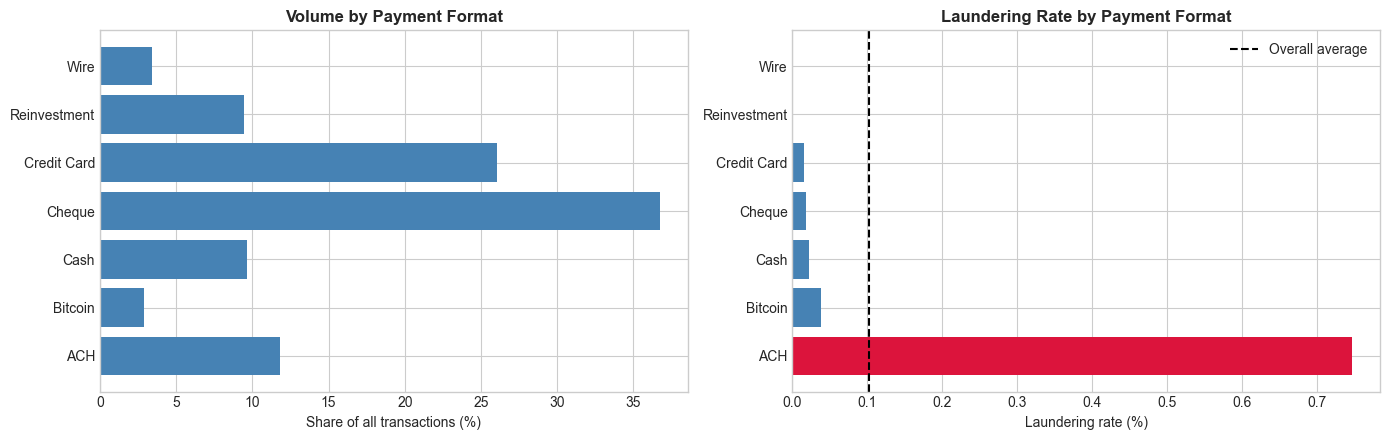

,Count,Laundering,Rate,Share (%)
Payment Format,,,,
ACH,600797,4483,0.0075,11.8306
Bitcoin,146091,56,0.0004,2.8767
Cash,490891,108,0.0002,9.6664
Cheque,1864331,324,0.0002,36.7114
Credit Card,1323324,206,0.0002,26.0582
Reinvestment,481056,0,0.0000,9.4727
Wire,171855,0,0.0000,3.3841


In [19]:
fmt = (df.groupby('Payment Format')['Is Laundering']
         .agg(Count='count', Laundering='sum', Rate='mean')
         .sort_values('Rate', ascending=False))
fmt['Share (%)'] = fmt['Count'] / len(df) * 100
overall = df['Is Laundering'].mean()

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

axes[0].barh(fmt.index, fmt['Share (%)'], color='steelblue')
axes[0].set_xlabel('Share of all transactions (%)')
axes[0].set_title('Volume by Payment Format', fontweight='bold')

colors = ['crimson' if r > overall else 'steelblue' for r in fmt['Rate']]
axes[1].barh(fmt.index, fmt['Rate'] * 100, color=colors)
axes[1].axvline(overall * 100, color='black', ls='--', label='Overall average')
axes[1].set_xlabel('Laundering rate (%)')
axes[1].set_title('Laundering Rate by Payment Format', fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.show()

fmt.round(4)

### Interpretation

- **ACH dominates the risk signal**: only 11.8% of volume but a **0.75% laundering rate — over 7× the overall average**. It is the single strongest categorical predictor in the dataset.
- **Cheque and Credit Card** carry most volume (36.7% and 26.1%) but laundering rates ~6× *below* average — launderers avoid high-volume, heavily monitored retail channels.
- **Reinvestment and Wire** contain **zero** laundering transactions.
- **Bitcoin is below average here** (0.038%) — notably different from LI-Small, where it was above average. Findings from one synthetic variant do not automatically transfer to another.
- **Feature engineering:** one-hot encode payment format; an explicit `Is_ACH` flag is justified as a targeted high-risk indicator.

## 8. Currency Analysis

Multi-currency flows are a hallmark of the *layering* stage of laundering, where funds cross jurisdictions to obscure their origin. We check the currency distribution and whether a **currency mismatch** (payment currency ≠ receiving currency) carries laundering signal.

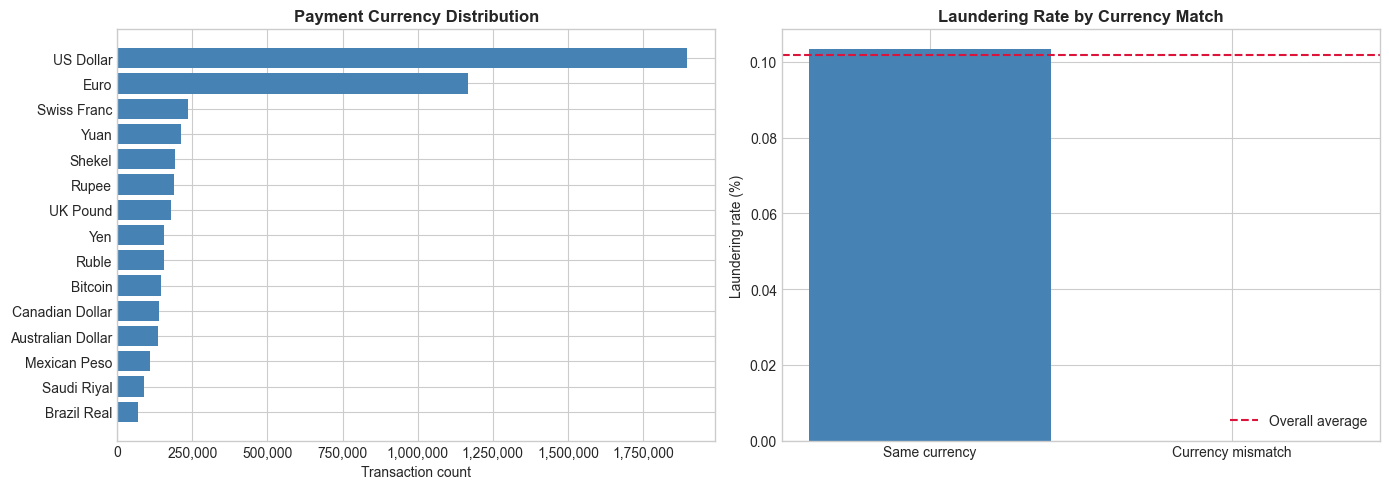

Currency mismatch share: 1.42%   laundering rate within mismatch: 0.0000%


In [20]:
ccy_counts = df['Payment Currency'].value_counts()
df['Currency Mismatch'] = (df['Payment Currency'] != df['Receiving Currency']).astype(int)
mismatch = df['Currency Mismatch'] == 1

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].barh(ccy_counts.index[::-1], ccy_counts.values[::-1], color='steelblue')
axes[0].set_xlabel('Transaction count')
axes[0].set_title('Payment Currency Distribution', fontweight='bold')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

rates = [df.loc[~mismatch, 'Is Laundering'].mean() * 100,
         df.loc[mismatch, 'Is Laundering'].mean() * 100]
axes[1].bar(['Same currency', 'Currency mismatch'], rates,
            color=['steelblue', 'darkorange'])
axes[1].axhline(df['Is Laundering'].mean() * 100, color='crimson', ls='--',
                label='Overall average')
axes[1].set_ylabel('Laundering rate (%)')
axes[1].set_title('Laundering Rate by Currency Match', fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f'Currency mismatch share: {mismatch.mean():.2%}   '
      f'laundering rate within mismatch: {df.loc[mismatch, "Is Laundering"].mean():.4%}')

### Interpretation

- **US Dollar dominates** both sides; all 15 currencies appear symmetrically as payment and receiving currency.
- **Currency mismatch transactions (1.42% of total) contain zero laundering** — contrary to real-world AML intuition, cross-currency conversion is *not* a laundering signal in this synthetic dataset.
- **Feature engineering:** `Currency_Mismatch` carries no predictive signal here and can be deprioritised or dropped.

## 9. Network / Graph Structure Analysis

The core motivation for GNNs: laundering is a property of **patterns across connected transactions**, not of single transactions. We examine self-loops, degree distributions, and whether hub accounts are riskier.

In [22]:
self_loop = df['From Account'] == df['To Account']
print(f'Self-loop transactions:    {self_loop.sum():,} ({self_loop.mean():.2%} of total)')
print(f'Self-loop laundering rate: {df.loc[self_loop, "Is Laundering"].mean():.4%}')
print()
print('Payment formats of self-loops:')
print(df.loc[self_loop, 'Payment Format'].value_counts().to_string())

Self-loop transactions:    591,212 (11.64% of total)
Self-loop laundering rate: 0.0019%

Payment formats of self-loops:
Payment Format
Reinvestment    481056
ACH              71347
Bitcoin          26317
Cheque            6066
Credit Card       4176
Cash              1455
Wire               795


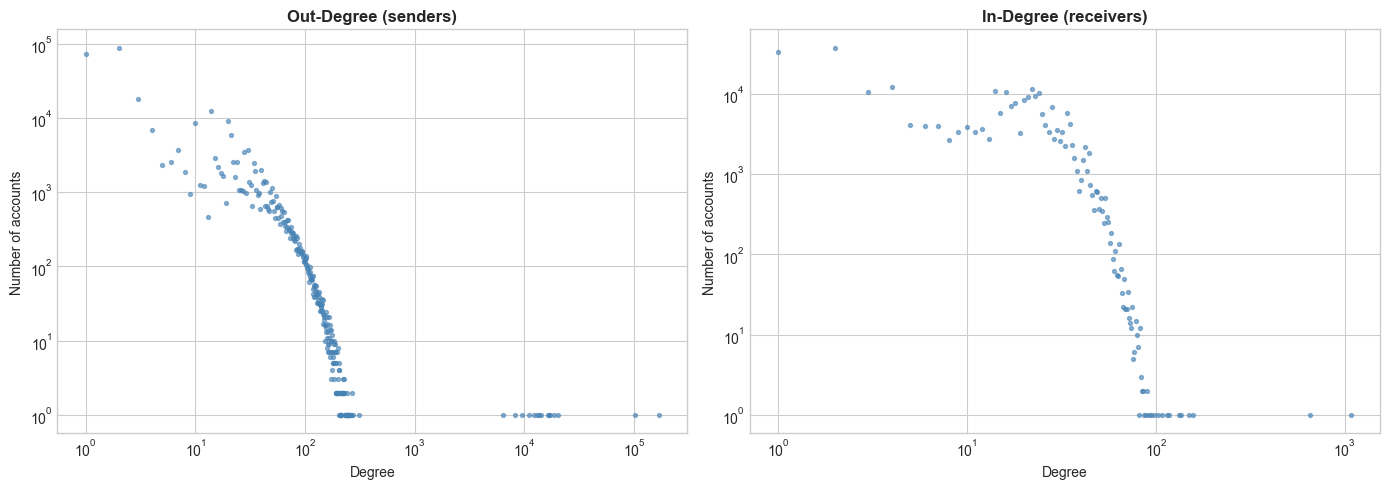

Out-degree: median = 2   max = 168,672
In-degree:  median = 16   max = 1,084
Laundering rate: top-1% in-degree hubs = 0.0946%   rest = 0.1159%


In [23]:
real_txn = df[~self_loop]
out_deg = real_txn.groupby('From Account').size()
in_deg  = real_txn.groupby('To Account').size()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, deg, title in [(axes[0], out_deg, 'Out-Degree (senders)'),
                       (axes[1], in_deg, 'In-Degree (receivers)')]:
    counts = deg.value_counts().sort_index()
    ax.scatter(counts.index, counts.values, s=8, alpha=0.6, color='steelblue')
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel('Degree')
    ax.set_ylabel('Number of accounts')
    ax.set_title(title, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Out-degree: median = {out_deg.median():.0f}   max = {out_deg.max():,}')
print(f'In-degree:  median = {in_deg.median():.0f}   max = {in_deg.max():,}')

# Are high in-degree hubs riskier than everyone else?
in_stats = real_txn.groupby('To Account')['Is Laundering'].agg(['count', 'sum'])
hub = in_stats['count'] >= in_stats['count'].quantile(0.99)
hub_rate  = in_stats.loc[hub, 'sum'].sum()  / in_stats.loc[hub, 'count'].sum()
rest_rate = in_stats.loc[~hub, 'sum'].sum() / in_stats.loc[~hub, 'count'].sum()
print(f'Laundering rate: top-1% in-degree hubs = {hub_rate:.4%}   rest = {rest_rate:.4%}')

### Interpretation

- **Self-loops (11.64% of transactions)** are dominated by Reinvestment (481K) plus ACH (71K) and Bitcoin (26K) entries, with a near-zero laundering rate (0.002%). They are excluded from degree computation and should be flagged (`Is_Self_Loop`) rather than treated as real fund movement.
- The **out-degree distribution follows a power law** (median 2, max 168,672) — a scale-free structure typical of financial networks. The **in-degree side is far tighter** (median 16, max 1,084), unlike LI-Small where extreme in-degree hubs existed: HI-Small senders concentrate, receivers do not.
- **Hub accounts are not riskier**: top-1% in-degree accounts have a *slightly lower* laundering rate (0.095%) than the rest (0.116%). High-volume hubs are legitimate institutions; **laundering lives in mid-degree accounts**, which is exactly the regime where GNN neighbourhood aggregation adds value over degree-based rules.

## 10. Account Entity Analysis

The accounts file maps each account to a bank and an **entity name**, whose leading word encodes the entity type. Different entity types carry different real-world risk profiles (e.g., shell corporations in layering), so we measure the laundering rate of each type as transaction sender.

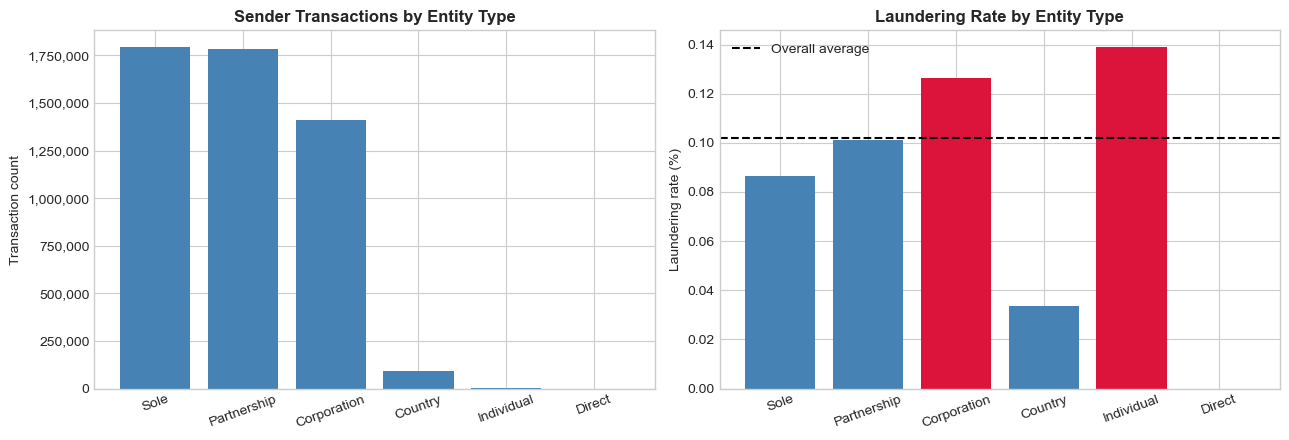

,Count,Rate
Entity Type,,
Sole,1790833,0.0009
Partnership,1781379,0.0010
Corporation,1409505,0.0013
Country,91852,0.0003
Individual,4323,0.0014
Direct,503,0.0000


In [15]:
acc_map = accounts[['Account Number', 'Entity Name']].copy()
acc_map['Entity Type'] = acc_map['Entity Name'].str.extract(r'^([A-Za-z]+)', expand=False)

ent = (df[['From Account', 'Is Laundering']]
       .merge(acc_map.rename(columns={'Account Number': 'From Account'}),
              on='From Account', how='left')
       .groupby('Entity Type')['Is Laundering']
       .agg(Count='count', Rate='mean')
       .sort_values('Count', ascending=False))

overall = df['Is Laundering'].mean()
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].bar(ent.index, ent['Count'], color='steelblue')
axes[0].set_ylabel('Transaction count')
axes[0].set_title('Sender Transactions by Entity Type', fontweight='bold')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
axes[0].tick_params(axis='x', rotation=20)

colors = ['crimson' if r > overall else 'steelblue' for r in ent['Rate']]
axes[1].bar(ent.index, ent['Rate'] * 100, color=colors)
axes[1].axhline(overall * 100, color='black', ls='--', label='Overall average')
axes[1].set_ylabel('Laundering rate (%)')
axes[1].set_title('Laundering Rate by Entity Type', fontweight='bold')
axes[1].tick_params(axis='x', rotation=20)
axes[1].legend()

plt.tight_layout()
plt.show()

ent.round(5)

### Interpretation

- HI-Small has **six entity types**; Partnership, Corporation, and Sole Proprietorship dominate both the account population and transaction volume, while Country, Individual, and Direct are rare.
- **Individual (0.139%) and Corporation (0.127%)** are the only types with above-average laundering rates — Individual despite tiny volume (4.3K transactions), Corporation consistent with shell-company layering.
- **Sole Proprietorship (0.087%)** and especially **Country (0.034%)** sit below average; the tiny Direct category has zero laundering.
- **Feature engineering:** one-hot encode entity type as an **account node feature**.

## 11. Laundering Pattern Typologies

`HI-Small_Patterns.txt` annotates every laundering *attempt* with its typology, delimited by `BEGIN/END LAUNDERING ATTEMPT` markers. The 8 pattern types from Altman et al. (2023):

| Pattern | Graph shape | Description |
|---------|-------------|-------------|
| **Fan-Out** | Star (one→many) | One account distributes to many recipients |
| **Fan-In** | Star (many→one) | Many accounts consolidate into one |
| **Gather-Scatter** | Hub | Fan-in followed by fan-out at the same vertex |
| **Scatter-Gather** | Bipartite | Fan-out then fan-in through intermediaries |
| **Cycle** | Ring | Funds circulate back to the origin |
| **Random** | Random walk | Multi-hop chain without returning to origin |
| **Bipartite** | Bipartite | A set of sources pays a set of destinations |
| **Stack** | Layered bipartite | Two stacked bipartite layers |

The typology mix tells us **which graph structures the GNN must learn to detect**.

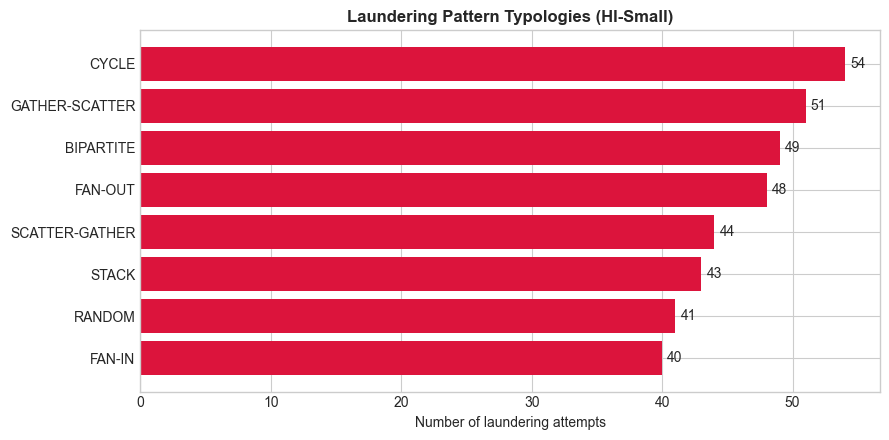

Total laundering attempts: 370   distinct base types: 8


In [24]:
with open('Data/HI-Small_Patterns.txt') as f:
    pattern_text = f.read()

attempts = re.findall(r'BEGIN LAUNDERING ATTEMPT - (.+)', pattern_text)
base_counts = Counter(a.split(':')[0].strip() for a in attempts)

names, counts = zip(*sorted(base_counts.items(), key=lambda x: x[1]))
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.barh(names, counts, color='crimson')
ax.set_xlabel('Number of laundering attempts')
ax.set_title('Laundering Pattern Typologies (HI-Small)', fontweight='bold')
for i, v in enumerate(counts):
    ax.text(v + 0.4, i, str(v), va='center')
plt.tight_layout()
plt.show()

print(f'Total laundering attempts: {len(attempts)}   distinct base types: {len(base_counts)}')

### Interpretation

- HI-Small contains **370 laundering attempts** — more than 3× the 117 in LI-Small — and they are **nearly balanced across all 8 typologies** (40–54 each), whereas LI-Small was skewed toward Stack/Bipartite. This balance gives the GNN supervision on every structural pattern.
- **Cycle (54)** and **Gather-Scatter (51)** are the most frequent — both require reasoning over **multi-hop, temporally ordered** flows.
- **GNN implication:** at least **2-layer message passing with edge features** is needed for the layered patterns (Stack, Bipartite, Scatter-Gather), and cycle-aware structural features (e.g., IBM's Graph Feature Preprocessor) are well-motivated given Cycle is the top typology.

## 12. Summary & Feature-Engineering Decisions

In [25]:
summary = pd.DataFrame({
    'Metric': [
        'Total transactions', 'Date range', 'Unique accounts',
        'Laundering transactions', 'Laundering rate',
        'Median amount (USD)', 'p99 amount (USD)',
        'Payment formats', 'Currencies',
        'Currency mismatch share', 'Self-loop share',
        'Laundering pattern attempts',
    ],
    'Value': [
        f'{len(df):,}',
        f'{df["Timestamp"].min().date()} to {df["Timestamp"].max().date()}',
        f'{pd.concat([df["From Account"], df["To Account"]]).nunique():,}',
        f'{df["Is Laundering"].sum():,}',
        f'{df["Is Laundering"].mean():.4%}',
        f'${df["Amount_USD"].median():,.0f}',
        f'${df["Amount_USD"].quantile(0.99):,.0f}',
        f'{df["Payment Format"].nunique()}',
        f'{df["Payment Currency"].nunique()}',
        f'{df["Currency Mismatch"].mean():.2%}',
        f'{self_loop.mean():.2%}',
        f'{len(attempts)}',
    ],
})
summary

,Metric,Value
0,Total transactions,"5,078,345"
1,Date range,2022-09-01 to 2022-09-18
2,Unique accounts,"515,080"
3,Laundering transactions,"5,177"
4,Laundering rate,0.1019%
5,Median amount (USD),$863
6,p99 amount (USD),"$3,031,008"
7,Payment formats,7
8,Currencies,15
9,Currency mismatch share,1.42%


### Key Findings

| Finding | Detail |
|---------|--------|
| **Class imbalance** | 0.102% laundering rate (1 : 980) — 2× LI-Small |
| **Amounts need FX correction** | 15 currencies; USD-converted laundering amounts concentrate at \$2K–\$13K |
| **Temporal truncation** | Real volume only 09-01 → 09-10; near-zero afterwards |
| **Business-hours + weekend signal** | Midday peak (0.17%); Sunday ~3× weekday rates |
| **ACH is the dominant risk format** | 0.75% laundering rate, 7× overall average |
| **Currency mismatch is no signal** | Zero laundering in cross-currency transactions |
| **Self-loops** | 11.6% of rows, mostly Reinvestment, near-zero risk |
| **Hubs are clean** | Top-1% in-degree accounts *below* average risk; laundering sits in mid-degree accounts |
| **Entity types** | Individual & Corporation above average risk |
| **Balanced typologies** | 370 attempts spread evenly over all 8 patterns; Cycle most common |

### Feature-Engineering Decisions for the GNN Pipeline

**Edge (transaction) features**
- `Amount_Log = log1p(Amount_USD)` with day-specific FX conversion
- Payment format one-hot (7) + explicit `Is_ACH` flag
- Cyclical hour and day-of-week encodings + `Is_Weekend`
- `Is_Self_Loop` flag (self-loops excluded from message passing)
- Drop `Currency_Mismatch` (zero signal)

**Node (account) features**
- Entity type one-hot (6)
- Bank identifier (normalised)
- Degree statistics (in/out degree, amounts aggregates)

**Training setup**
- Class-weighted loss (≈1000× minority weight) or minority oversampling
- Evaluation via minority-class F1 / PR-AUC, never accuracy
- **Temporal split** respecting the truncated tail after 09-10
- ≥2-layer message passing with edge features; cycle-aware structural features (GFP) motivated by the typology mix